# Titanic Visualisations

Visual analysis of the Titanic dataset. Requires `train_data` to be loaded — run `model.ipynb` cells 1–2 first, or run the data loading cell below.

In [1]:
import pandas as pd

# Load and preprocess training data
train_data = pd.read_csv("train.csv")
train_data['Age'].fillna(train_data['Age'].mean(), inplace=True)
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})

C:\Users\BenCliffe\AppData\Local\Temp\ipykernel_16528\3978390108.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].mean(), inplace=True)


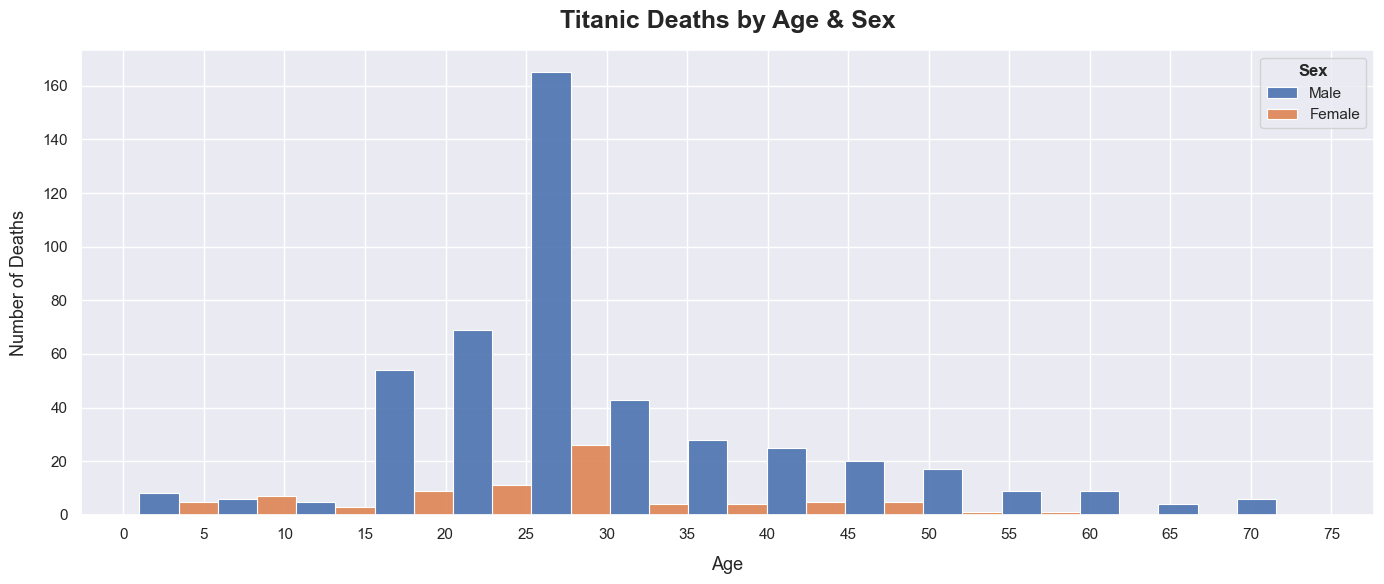

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
 
sns.set_theme(style="darkgrid", palette="deep")

# Map encoded columns back to readable labels for display
train_data['Survival Status'] = train_data['Survived'].map({0: 'Died', 1: 'Survived'})
train_data['Sex Label'] = train_data['Sex'].map({0: 'Male', 1: 'Female'})

# Filter to only passengers who died
died_data = train_data[train_data['Survival Status'] == 'Died']

fig, ax = plt.subplots(figsize=(14, 6))

# Plot age distribution of deaths split by sex, using 5-year bins side by side
sns.histplot(
    data=died_data,
    x='Age',
    hue='Sex Label',
    binwidth=5,
    multiple='dodge',
    palette={'Male': '#4C72B0', 'Female': '#DD8452'},
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9,
    ax=ax
)

ax.set_title('Titanic Deaths by Age & Sex', fontsize=18, fontweight='bold', pad=16)
ax.set_xlabel('Age', fontsize=13, labelpad=10)
ax.set_ylabel('Number of Deaths', fontsize=13, labelpad=10)
# Tick every 5 years to align with bin edges
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.tick_params(axis='both', labelsize=11)

legend = ax.get_legend()
legend.set_title('Sex', prop={'size': 12, 'weight': 'bold'})
for text in legend.get_texts():
    text.set_fontsize(11)

plt.tight_layout()
plt.show()